# Predicting **Severe (Complicated) vs Non-Severe** Pediatric Appendicitis — a model benchmark
### Reproducing the metrics of Marcinkevics et al. (2024) and testing newer algorithms on the same task

This notebook isolates the **severity** target (complicated vs uncomplicated) of the **Regensburg Pediatric Appendicitis** dataset (UCI ID 938) and benchmarks several modern classifiers against the published results of:

> Marcinkevics R., Reis Wolfertstetter P., Klimiene U., et al. *Interpretable and intervenable ultrasonography-based machine learning models for pediatric appendicitis.* **Medical Image Analysis** 91 (2024) 103042.

Their best **severity** result (ultrasound-image-only): **AUROC ~ 0.77, AUPR ~ 0.58, Brier ~ 0.15** (Radiomics + Random Forest). We test, on the **tabular** clinical/lab/score/US-finding data, whether modern tabular learners can match or beat it.

**Models:** Elastic-net Logistic Regression, cost-sensitive Random Forest, Balanced Random Forest, XGBoost, **CatBoost**, **Explainable Boosting Machine (EBM)**, **TabPFN v2** (ready-to-run; needs a one-time free license acceptance).

**How to use with the real data:** the dataset auto-downloads from UCI on first run (`ucimlrepo`). To use any updated CSV, point `DATA_PATH` at it and *Restart & Run All*.

> Educational/methodological benchmark - not medical advice or a validated clinical tool. Numbers are produced under a matched but **not identical** protocol to the paper (different modality/inputs), so comparisons are indicative.

## 0. Install dependencies (run once if needed)
```
pip install ucimlrepo scikit-learn xgboost catboost imbalanced-learn interpret pandas numpy matplotlib joblib
# optional (gated, needs one-time license acceptance):  pip install tabpfn
```

In [1]:
import os, warnings; warnings.filterwarnings("ignore")
os.environ.setdefault("TABPFN_NO_BROWSER", "1")  # prevent TabPFN from opening an interactive login
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (roc_auc_score, average_precision_score, brier_score_loss,
                             roc_curve, precision_recall_curve)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
from imblearn.ensemble import BalancedRandomForestClassifier
from catboost import CatBoostClassifier
from interpret.glassbox import ExplainableBoostingClassifier
import joblib
print("Imports OK | xgboost", xgb.__version__)

Imports OK | xgboost 3.3.0


## 1. Configuration

In [2]:
DATA_PATH      = "regensburg_appendicitis.csv"   # auto-downloaded if missing
TARGET_COL     = "Severity"
POSITIVE_LABEL = "complicated"                    # severe class
RANDOM_STATE   = 42
N_REPEATS      = 5         # repeats of 5-fold CV (raise to 10 for the paper's protocol)

# Leakage-safe exclusions for the SEVERITY task (complicated = abscess / gangrene / perforation):
LEAK_COLS = ["Management", "Severity", "Diagnosis",                      # targets / other labels
             "Perforation", "Appendicular_Abscess", "Abscess_Location",  # definitional (perforation/abscess)
             "Perfusion",                                                # gangrene proxy (hypoperfusion)
             "Length_of_Stay",                                           # post-hoc outcome
             "Gynecological_Findings", "Lymph_Nodes_Location"]           # unusable free-text

## 2. Load data (auto-download from UCI if absent)

In [3]:
try:
    df = pd.read_csv(DATA_PATH)
except FileNotFoundError:
    from ucimlrepo import fetch_ucirepo
    d = fetch_ucirepo(id=938)
    df = d.data.features.join(d.data.targets)
    df.to_csv(DATA_PATH, index=False)
    print("Downloaded from UCI ->", DATA_PATH)

df = df[df[TARGET_COL].notna()].reset_index(drop=True)
y = (df[TARGET_COL].astype(str).str.strip() == POSITIVE_LABEL).astype(int).values
print("rows:", len(df), "| complicated:", int(y.sum()), "(%.1f%%)" % (100*y.mean()))

rows: 781 | complicated: 119 (15.2%)


## 3. Build a leakage-safe feature matrix
Severity is *defined* by perforation, abscess or gangrene, so those columns (and post-hoc outcomes / other labels) are removed - otherwise the model would "predict" the answer from columns that encode it. Continuous variables are kept continuous; categoricals are one-hot encoded with an explicit missing indicator.

In [4]:
feat = [c for c in df.columns if c not in LEAK_COLS]
Xraw = df[feat].copy()
num = [c for c in Xraw.columns if pd.api.types.is_numeric_dtype(Xraw[c])]
cat = [c for c in Xraw.columns if c not in num]
Xraw[cat] = Xraw[cat].astype("object")
Xcat = pd.get_dummies(Xraw[cat], dummy_na=True).astype(float)
X = pd.concat([Xraw[num].astype(float), Xcat], axis=1)
print("predictors:", len(feat), "| numeric:", len(num), "| categorical:", len(cat),
      "| design matrix:", X.shape)
print("excluded as leakage:", LEAK_COLS)

predictors: 46 | numeric: 16 | categorical: 30 | design matrix: (781, 118)
excluded as leakage: ['Management', 'Severity', 'Diagnosis', 'Perforation', 'Appendicular_Abscess', 'Abscess_Location', 'Perfusion', 'Length_of_Stay', 'Gynecological_Findings', 'Lymph_Nodes_Location']


## 4. Models
Shallow, regularised, class-balanced configurations suited to a small (~781), imbalanced (~15%) dataset. All models receive the **same** design matrix for a fair comparison.

In [5]:
spw = float((y==0).sum()/(y==1).sum())
def make_models():
    return {
      "Elastic-net LogReg": Pipeline([("imp",SimpleImputer(strategy="median")),("sc",StandardScaler()),
          ("clf",LogisticRegression(penalty="elasticnet",solver="saga",l1_ratio=0.5,C=0.3,
                                    max_iter=5000,class_weight="balanced"))]),
      "RF (cost-sensitive)": Pipeline([("imp",SimpleImputer(strategy="median")),
          ("clf",RandomForestClassifier(n_estimators=400,class_weight="balanced_subsample",
                                        min_samples_leaf=2,random_state=RANDOM_STATE,n_jobs=-1))]),
      "Balanced RF": Pipeline([("imp",SimpleImputer(strategy="median")),
          ("clf",BalancedRandomForestClassifier(n_estimators=400,sampling_strategy="all",
                 replacement=True,bootstrap=True,random_state=RANDOM_STATE,n_jobs=-1))]),
      "XGBoost": Pipeline([("clf",xgb.XGBClassifier(n_estimators=300,max_depth=3,learning_rate=0.05,
                 subsample=0.9,colsample_bytree=0.8,reg_lambda=5.0,eval_metric="auc",
                 scale_pos_weight=spw,tree_method="hist",random_state=RANDOM_STATE))]),
      "CatBoost": Pipeline([("imp",SimpleImputer(strategy="median")),
          ("clf",CatBoostClassifier(iterations=400,depth=4,learning_rate=0.05,l2_leaf_reg=6,
                 auto_class_weights="Balanced",verbose=0,random_seed=RANDOM_STATE))]),
      "EBM": Pipeline([("imp",SimpleImputer(strategy="median")),
          ("clf",ExplainableBoostingClassifier(interactions=0,outer_bags=8,random_state=RANDOM_STATE))]),
    }
print("scale_pos_weight = %.2f" % spw, "| models:", list(make_models()))

scale_pos_weight = 5.56 | models: ['Elastic-net LogReg', 'RF (cost-sensitive)', 'Balanced RF', 'XGBoost', 'CatBoost', 'EBM']


## 5. Evaluation - repeated stratified cross-validation
For each model and each of `N_REPEATS` seeds we take **out-of-fold** predictions over 5 folds and compute AUROC, AUPR and Brier on the full OOF set, then report mean +/- sd across repeats (mirroring the paper's 10 initialisations). OOF metrics are honest (every prediction is on held-out data).

In [6]:
results, oof_store = [], {}
for name in make_models():
    a,p,b = [],[],[]
    last=None
    for r in range(N_REPEATS):
        cv = StratifiedKFold(5, shuffle=True, random_state=1000+r)
        oof = cross_val_predict(make_models()[name], X, y, cv=cv, method="predict_proba", n_jobs=-1)[:,1]
        a.append(roc_auc_score(y,oof)); p.append(average_precision_score(y,oof))
        b.append(brier_score_loss(y,oof)); last=oof
    oof_store[name]=last
    results.append({"Model":name,"AUROC":np.mean(a),"AUROC_sd":np.std(a),
                    "AUPR":np.mean(p),"AUPR_sd":np.std(p),"Brier":np.mean(b),"Brier_sd":np.std(b)})
    print(f"{name:22s} AUROC {np.mean(a):.3f}+/-{np.std(a):.3f} | AUPR {np.mean(p):.3f} | Brier {np.mean(b):.3f}")
res = pd.DataFrame(results).sort_values("AUROC", ascending=False).reset_index(drop=True)
res.round(3)

Elastic-net LogReg     AUROC 0.891+/-0.004 | AUPR 0.642 | Brier 0.103


RF (cost-sensitive)    AUROC 0.915+/-0.003 | AUPR 0.635 | Brier 0.083


Balanced RF            AUROC 0.914+/-0.002 | AUPR 0.617 | Brier 0.116


XGBoost                AUROC 0.905+/-0.005 | AUPR 0.625 | Brier 0.092


CatBoost               AUROC 0.907+/-0.004 | AUPR 0.644 | Brier 0.088


EBM                    AUROC 0.914+/-0.004 | AUPR 0.681 | Brier 0.077


,Model,AUROC,AUROC_sd,AUPR,AUPR_sd,Brier,Brier_sd
0,RF (cost-sensitive),0.915,0.003,0.635,0.013,0.083,0.001
1,Balanced RF,0.914,0.002,0.617,0.007,0.116,0.000
2,EBM,0.914,0.004,0.681,0.016,0.077,0.001
3,CatBoost,0.907,0.004,0.644,0.014,0.088,0.001
4,XGBoost,0.905,0.005,0.625,0.019,0.092,0.002
5,Elastic-net LogReg,0.891,0.004,0.642,0.017,0.103,0.004


## 6. TabPFN v2 (ready-to-run - one-time license acceptance required)
TabPFN v2 is a tabular **foundation model** ideal for small datasets. Its weights are gated: accept the free licence once via an interactive `import tabpfn` login **or** set `TABPFN_TOKEN`. This cell runs it if available and otherwise skips cleanly.

In [7]:
try:
    from tabpfn import TabPFNClassifier
    a,p,b=[],[],[]
    for r in range(N_REPEATS):
        cv = StratifiedKFold(5, shuffle=True, random_state=1000+r)
        clf = Pipeline([("imp",SimpleImputer(strategy="median")),("clf",TabPFNClassifier())])
        oof = cross_val_predict(clf, X, y, cv=cv, method="predict_proba")[:,1]
        a.append(roc_auc_score(y,oof)); p.append(average_precision_score(y,oof)); b.append(brier_score_loss(y,oof))
    row={"Model":"TabPFN v2","AUROC":np.mean(a),"AUROC_sd":np.std(a),"AUPR":np.mean(p),
         "AUPR_sd":np.std(p),"Brier":np.mean(b),"Brier_sd":np.std(b)}
    res = pd.concat([res, pd.DataFrame([row])], ignore_index=True).sort_values("AUROC",ascending=False).reset_index(drop=True)
    print("TabPFN v2  AUROC %.3f | AUPR %.3f | Brier %.3f" % (np.mean(a),np.mean(p),np.mean(b)))
except Exception as e:
    print("TabPFN skipped (%s: %s)." % (type(e).__name__, str(e)[:120]))
    print("To enable: pip install tabpfn, then accept the licence once (interactive) or set TABPFN_TOKEN.")

TabPFN skipped (TabPFNLicenseError: TabPFN requires a one-time license acceptance to download
model weights for local inference, but browser login is
disabl).
To enable: pip install tabpfn, then accept the licence once (interactive) or set TABPFN_TOKEN.


## 7. Comparison with Marcinkevics et al. (2024) - severity task

In [8]:
paper = pd.DataFrame([
    ["Marcinkevics 2024 - Radiomics+RF (best)", 0.77, 0.58, 0.15],
    ["Marcinkevics 2024 - MVBM-LSTM (black-box)", 0.74, 0.58, 0.22],
    ["Marcinkevics 2024 - ResNet-18", 0.73, 0.52, 0.18],
    ["Marcinkevics 2024 - CBM (interpretable)", 0.68, 0.44, 0.23],
], columns=["Model","AUROC","AUPR","Brier"])
ours = res[["Model","AUROC","AUPR","Brier"]].copy(); ours["Model"] = "This work - " + ours["Model"]
compare = pd.concat([paper, ours], ignore_index=True)
compare.round(3)

,Model,AUROC,AUPR,Brier
0,Marcinkevics 2024 - Radiomics+RF (best),0.770,0.580,0.150
1,Marcinkevics 2024 - MVBM-LSTM (black-box),0.740,0.580,0.220
2,Marcinkevics 2024 - ResNet-18,0.730,0.520,0.180
3,Marcinkevics 2024 - CBM (interpretable),0.680,0.440,0.230
4,This work - RF (cost-sensitive),0.915,0.635,0.083
5,This work - Balanced RF,0.914,0.617,0.116
6,This work - EBM,0.914,0.681,0.077
7,This work - CatBoost,0.907,0.644,0.088
8,This work - XGBoost,0.905,0.625,0.092
9,This work - Elastic-net LogReg,0.891,0.642,0.103


## 8. Curves and a performance bar chart

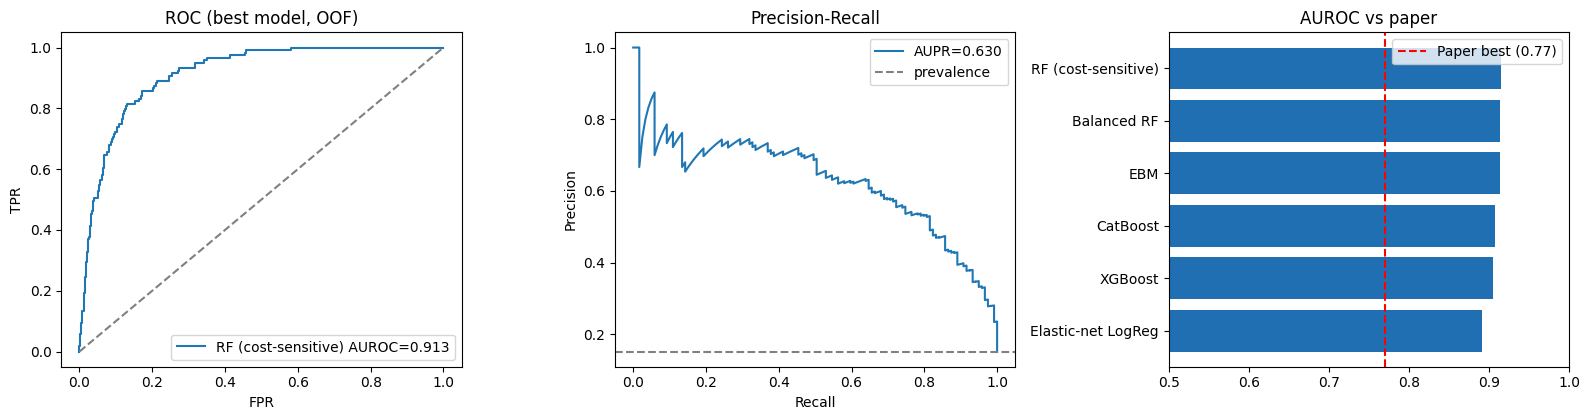

In [9]:
best = res.iloc[0]["Model"]; yv = y; pv = oof_store.get(best, list(oof_store.values())[0])
fig, ax = plt.subplots(1,3, figsize=(16,4.3))
fpr,tpr,_ = roc_curve(yv,pv); ax[0].plot(fpr,tpr,label=f"{best} AUROC={roc_auc_score(yv,pv):.3f}")
ax[0].plot([0,1],[0,1],"--",c="grey"); ax[0].set_title("ROC (best model, OOF)"); ax[0].set_xlabel("FPR"); ax[0].set_ylabel("TPR"); ax[0].legend()
pr,rc,_ = precision_recall_curve(yv,pv); ax[1].plot(rc,pr,label=f"AUPR={average_precision_score(yv,pv):.3f}")
ax[1].axhline(yv.mean(),ls="--",c="grey",label="prevalence"); ax[1].set_title("Precision-Recall"); ax[1].set_xlabel("Recall"); ax[1].set_ylabel("Precision"); ax[1].legend()
o = res.sort_values("AUROC"); ax[2].barh(o["Model"], o["AUROC"], color="#1F6FB2")
ax[2].axvline(0.77,ls="--",c="red",label="Paper best (0.77)"); ax[2].set_xlim(0.5,1.0); ax[2].set_title("AUROC vs paper"); ax[2].legend()
plt.tight_layout(); plt.show()

## 9. Interpretability - EBM global feature importance
The Explainable Boosting Machine is a glass-box model; its global importances show which clinical/US features drive predicted *complicated* appendicitis.

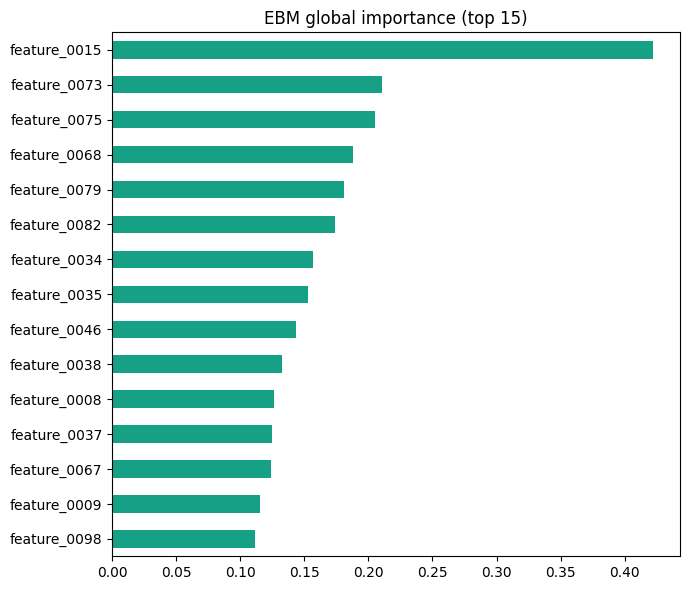

In [10]:
ebm = make_models()["EBM"].fit(X, y)
g = ebm.named_steps["clf"].explain_global()
names = g.data()["names"]; scores = g.data()["scores"]
imp = pd.Series(scores, index=names).sort_values()
imp.tail(15).plot(kind="barh", figsize=(7,6), color="#16A085", title="EBM global importance (top 15)")
plt.tight_layout(); plt.show()

## 10. Save artefacts

In [11]:
res.to_csv("severity_benchmark_results.csv", index=False)
compare.to_csv("severity_comparison_vs_paper.csv", index=False)
print("Saved severity_benchmark_results.csv and severity_comparison_vs_paper.csv")

Saved severity_benchmark_results.csv and severity_comparison_vs_paper.csv


## 11. Optional - ultrasound image branch (MedSigLIP), scaffold only
The paper used the abdominal **ultrasound images** (hosted separately on Zenodo, several GB). To extend this benchmark with imaging, extract per-image embeddings with a medical foundation encoder (e.g. **google/medsiglip-448**, gated on Hugging Face, GPU recommended), aggregate per patient (mean or attention-MIL), and **late-fuse** with the tabular model. Not executed here (requires HF gated access + GPU + the image download).

```python
# from transformers import AutoModel, AutoProcessor
# proc = AutoProcessor.from_pretrained("google/medsiglip-448")
# enc  = AutoModel.from_pretrained("google/medsiglip-448")   # needs accepted licence + token
# emb  = encode_ultrasound_images(patient_images, enc, proc) # -> [n_patients, d]
# fuse emb with X (concatenate, or stack TabPFN/CatBoost on tabular + a classifier on emb)
```

## 12. Notes & caveats
- **Not identical to the paper:** Marcinkevics et al. predicted severity from **ultrasound images**; here we use the **tabular** clinical/lab/score/US-finding data. The comparison is *indicative*, not head-to-head.
- **Leakage discipline** is decisive: perforation/abscess/perfusion and post-hoc outcomes are excluded; revisit `LEAK_COLS` if the schema changes.
- **Small & imbalanced** (~119 positives): report AUPR + Brier and treat single-run "wins" cautiously; CIs are wide.
- **No clinical claim**: external validation, calibration in deployment and prospective testing are required before any use.